In [1]:
# Import packages
import nflreadpy
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
player_data = nflreadpy.load_player_stats(seasons=True, summary_level="reg")

# Select unnecessary columns
drop_columns = ["headshot_url", "season_type", "gwfg_made", "gwfg_att", "gwfg_missed",
                    "gwfg_blocked", "def_tackles_solo", "def_tackles_with_assist",
                    "def_tackle_assists", "def_tackles_for_loss", "def_tackles_for_loss_yards",
                    "def_fumbles_forced", "def_sacks", "def_sack_yards", "def_qb_hits",
                    "def_interceptions", "def_interception_yards", "def_pass_defended",
                    "def_tds", "def_fumbles", "def_safeties", "punt_returns", "fumble_recovery_own",
                    "fumble_recovery_yards_own", "fumble_recovery_opp", "fumble_recovery_yards_opp",
                    "fumble_recovery_tds", "punt_return_yards", "kickoff_returns", "kickoff_return_yards"]

player_data_cleaned = player_data.drop(drop_columns)
# Positional columns
qb_cols = ["player_display_name", "season", "completions", "attempts", "passing_yards", "passing_tds",
               "passing_interceptions", "sacks_suffered", "sack_yards_lost", "sack_fumbles",
               "sack_fumbles_lost", "passing_air_yards", "passing_yards_after_catch",
               "passing_first_downs", "passing_epa", "passing_cpoe", "passing_2pt_conversions",
               "pacr", "carries", "rushing_yards", "rushing_tds", "rushing_fumbles",
               "rushing_fumbles_lost", "rushing_first_downs", "rushing_epa",
               "rushing_2pt_conversions", "fantasy_points_ppr"]
# RBs, TEs, and WRs had many similar columns so they are combined into skill-position columns
sp_cols = ["player_display_name", "carries", "rushing_yards", "rushing_tds", "rushing_fumbles", 
               "rushing_fumbles_lost", "rushing_first_downs", "rushing_epa", "rushing_2pt_conversions",
               "receptions", "targets", "receiving_yards", "receiving_tds", "receiving_fumbles",
               "receiving_fumbles_lost", "receiving_air_yards", "receiving_yards_after_catch",
               "receiving_first_downs", "receiving_epa", "receiving_2pt_conversions", "racr",
               "target_share", "air_yards_share", "wopr", "fantasy_points_ppr"]
   

# Group players by position to build positional models
qbs = player_data_cleaned.filter(pl.col('position') == 'QB')[qb_cols]
rbs = player_data_cleaned.filter(pl.col('position') == 'RB')[sp_cols]
tes = player_data_cleaned.filter(pl.col('position') == 'TE')[sp_cols]
wrs = player_data_cleaned.filter(pl.col('position') == 'WR')[sp_cols]

In [3]:
"""
Feature Engineering for QBs
- Completion %
- yds/att
- td/int ratio
- sacks/game

Features for RBs

Features for TEs

Features for WRs
"""

qbs = qbs.with_columns(
    (pl.col("completions") / pl.col("attempts")).alias("completion_percentage").replace([float("inf"), float("-inf")], 0),
    (pl.col("passing_yards") / pl.col("attempts")).alias("yards_per_attempt").replace([float("inf"), float("-inf")], 0),
    (pl.col("passing_tds") / pl.col("passing_interceptions").alias("interception_ratio")).replace([float("inf"), float("-inf")], 0),
    (pl.col("sacks_suffered") / 18).alias("sacks_per_game").replace([float("inf"), float("-inf")], 0))

In [4]:
"""
This will be an ensemble model analysis that will be done using a variety of models: random forest, clustering, and linear regression
will be trained on the data and the predictions of these models will be fed along with original data into a neural network
"""
# Training linear regression model
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_predict
from sklearn.metrics import auc, accuracy_score, root_mean_squared_error, mean_squared_error, silhouette_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [5]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    ("standardizer", StandardScaler()),
])

In [6]:
def build_prediction_dataset(
    df: pl.DataFrame,
    target_col: str = "fantasy_points_ppr",
    id_cols: list[str] = ["player_display_name", "season"],
    lag: int = 1
):
    """
    Pairs each season's stats with the NEXT season's target.
    
    2024 stats → 2025 fantasy points
    2023 stats → 2024 fantasy points
    ...all the way back to 1999 stats → 2000 fantasy points
    """
    
    # Everything that isn't an ID or the target is a feature
    feature_cols = [c for c in df.columns if c not in id_cols + [target_col]]
    
    # Left side: the stats (features) — unchanged
    stats = df.select(*id_cols, *feature_cols)
    
    # Right side: the target — shift season back so it aligns with prior year
    targets = df.select(
        "player_display_name",
        (pl.col("season") - lag).alias("season"),  # 2025 becomes 2024, etc.
        target_col
    )
    
    # Join: every year's stats get paired with next year's outcome
    combined = stats.join(
        targets,
        on=["player_display_name", "season"],
        how="inner"  # drops players who don't appear in consecutive years
    )
    
    return combined


# --- Usage ---
combined = build_prediction_dataset(qbs)

# See what you got — one row per player per year pair
print(combined.shape)
print(combined.select("player_display_name", "season", "fantasy_points_ppr").sample(10))

X, y = combined.drop(pl.col(["player_display_name","fantasy_points_ppr"])), combined["fantasy_points_ppr"]

(1516, 30)
shape: (10, 3)
┌─────────────────────┬────────┬────────────────────┐
│ player_display_name ┆ season ┆ fantasy_points_ppr │
│ ---                 ┆ ---    ┆ ---                │
│ str                 ┆ i32    ┆ f64                │
╞═════════════════════╪════════╪════════════════════╡
│ Mark Brunell        ┆ 2005   ┆ 100.96             │
│ Tom Brady           ┆ 2016   ┆ 295.88             │
│ Brad Johnson        ┆ 1999   ┆ 120.0              │
│ Tarvaris Jackson    ┆ 2014   ┆ 0.68               │
│ AJ McCarron         ┆ 2019   ┆ 0.8                │
│ Jeff Blake          ┆ 2001   ┆ 123.96             │
│ Matt McGloin        ┆ 2015   ┆ 1.7                │
│ Teddy Bridgewater   ┆ 2017   ┆ 7.22               │
│ Robert Griffin III  ┆ 2019   ┆ 2.58               │
│ Charlie Whitehurst  ┆ 2015   ┆ 9.38               │
└─────────────────────┴────────┴────────────────────┘


In [7]:
def build_baseline_model(X_train, X_test, y_train, y_test, model_name: str, model, params: dict) -> pl.DataFrame:

    model_pipeline = Pipeline([
    ("preprocess", num_pipeline),
    (model_name, model)
    ])

    params_dist = params

    rand_model = RandomizedSearchCV(model_pipeline, param_distributions=params_dist, cv=10, n_jobs=-1, random_state=42)

    rand_model.fit(X_train, y_train)

    best_model = rand_model.best_estimator_
    predictions = cross_val_predict(best_model, X_train, y_train)

    return predictions

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

sgd_params = {"sgd__loss": ["squared_error", "huber", "epsilon_insensitive", "squared_epsilon_insensitive"],
              "sgd__penalty": ["l2", "l1", "elasticnet", None], "sgd__alpha": np.arange(1e-6, 0.1, 0.001),
              "sgd__learning_rate": ["constant", "optimal", "invscaling", "adaptive", "pa1", "pa2"],
              "sgd__early_stopping": [True, False], "sgd__warm_start": [True, False]}
rf_params = {"rf__loss": ["squared_error", "absolute_error", "huber", "quantile"], "rf__learning_rate": np.arange(1e-3, 3, 0.01),
             "rf__n_estimators": np.arange(100, 1000, 200), "rf__criterion": ["friedman_mse", "squared_error"],
             "rf__max_depth": np.arange(3, 20, 1), "rf__max_features": [None, "sqrt", "log2"], "rf__warm_start": [True, False]}

sgd_predictions = build_baseline_model(X_train, X_test, y_train, y_test, "sgd", SGDRegressor(max_iter=20_000), sgd_params)
rf_predictions = build_baseline_model(X_train, X_test, y_train, y_test, "rf", GradientBoostingRegressor(random_state=42), rf_params)

<Axes: xlabel='clusters', ylabel='scores'>

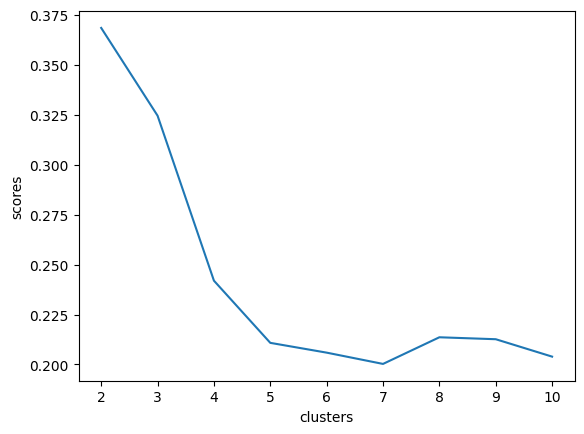

In [9]:
# Find best number of clusters for kmeans
scores = []
num_clusters = np.arange(2,11)
models = []
X_copy = num_pipeline.fit_transform(X)
X_copy = PCA(n_components=0.90).fit_transform(X_copy)

for n in num_clusters:
    kmeans = KMeans(n_clusters=n, n_init=10, random_state=42)
    kmeans.fit(X_copy)
    models.append(kmeans)
    scores.append(silhouette_score(X_copy, kmeans.labels_))

scores_df = pl.DataFrame({ "clusters": num_clusters, "scores": scores, "models": models})

best_model = scores_df.sort("scores", descending=True)["models"][0] # This is our best model that will give us the clusters

distances = best_model.transform(X_copy) # Final model predictions that will be used as a feature

sns.lineplot(data=scores_df[["clusters", "scores"]], x="clusters", y="scores")

In [10]:
X_clusters = pl.Series(best_model.transform(X_copy))

In [11]:
X_clusters

""
"array[f64, 2]"
"[3.914341, 5.218711]"
"[5.444069, 6.983879]"
"[3.925888, 4.727915]"
"[5.438716, 10.106028]"
"[4.142211, 7.73196]"
…
"[4.959646, 8.505623]"
"[4.002961, 7.684487]"
"[10.173617, 13.630204]"
